## Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn
What You’ll learn
Advanced data visualization techniques.
Interactive chart creation using Matplotlib.
Elegant static data presentation with Seaborn.


Your Task


1. Data Preparation:
Download and explore the US Superstore data.
Perform basic data cleaning and preprocessing.


2. Data Visualization with Matplotlib:
Create an interactive line chart to show sales trends over the years.
Build an interactive map to visualize sales distribution by country.


3. Data Visualization with Seaborn:
Use Seaborn to generate a bar chart showing top 10 products by sales.
Create a scatter plot to analyze the relationship between profit and discount.


4. Comparative Analysis:
Compare the insights gained from Matplotlib and Seaborn visualizations.
Document your observations about the ease of use and effectiveness of both tools.


5. Code and Insights:
Write clear, well-documented Python code.
Include your analysis and insights as comments or markdown cells in your Jupyter notebook.


Dataset Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

First rows:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688

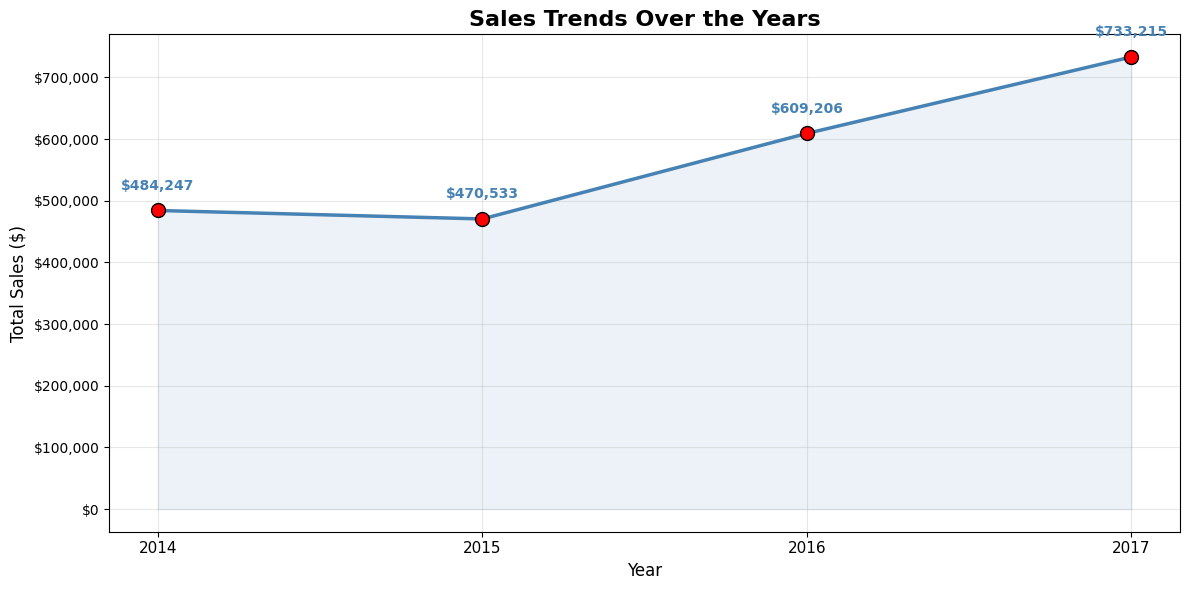


Yearly Sales Summary:
   Order Year        Sales
0        2014  484247.4981
1        2015  470532.5090
2        2016  609205.5980
3        2017  733215.2552


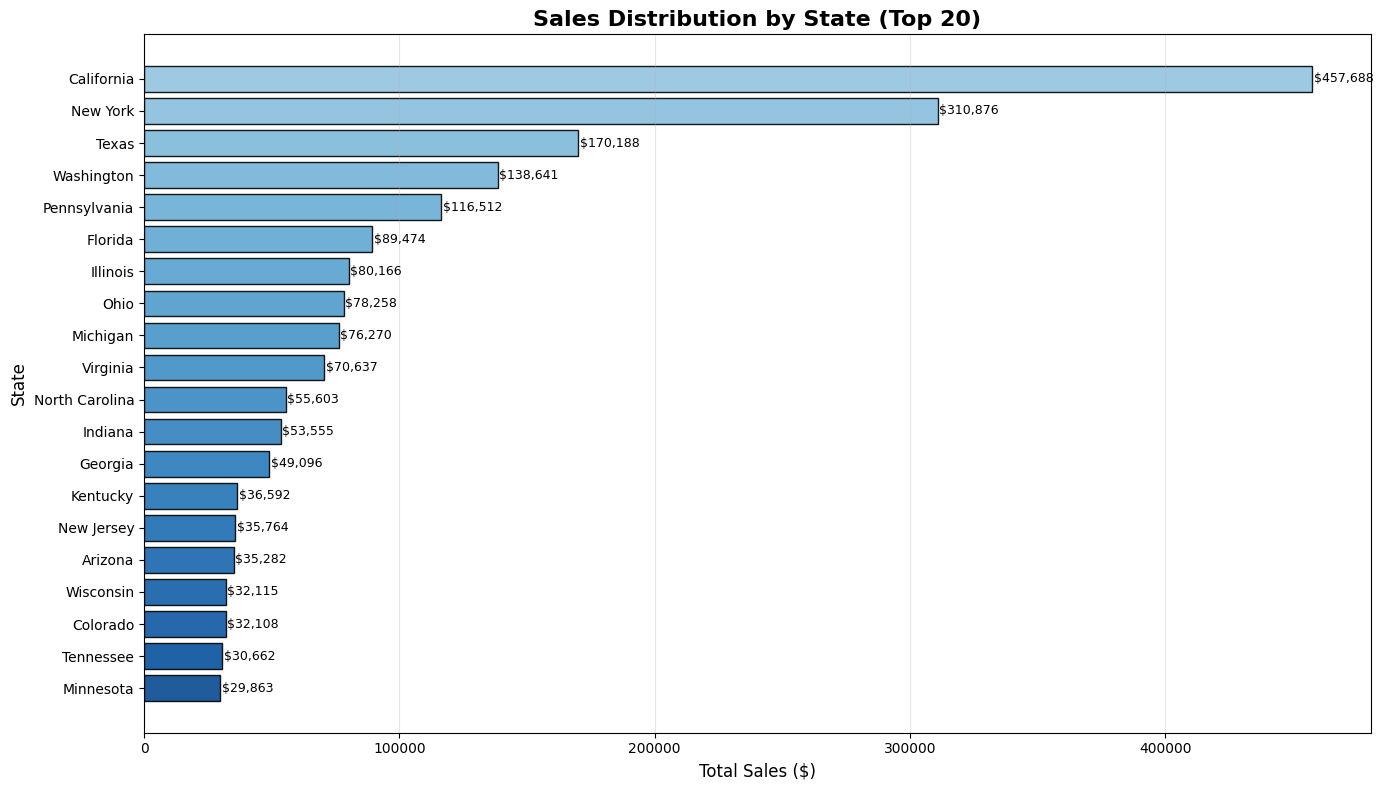

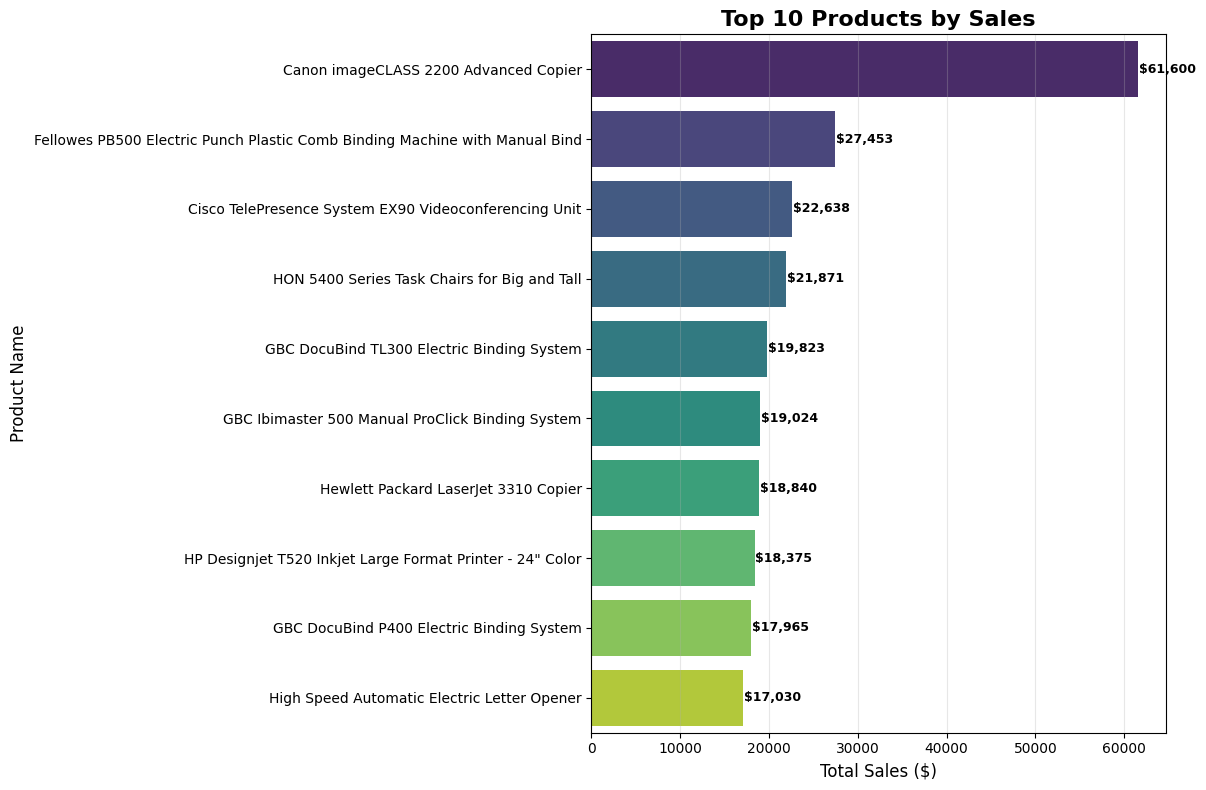


Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


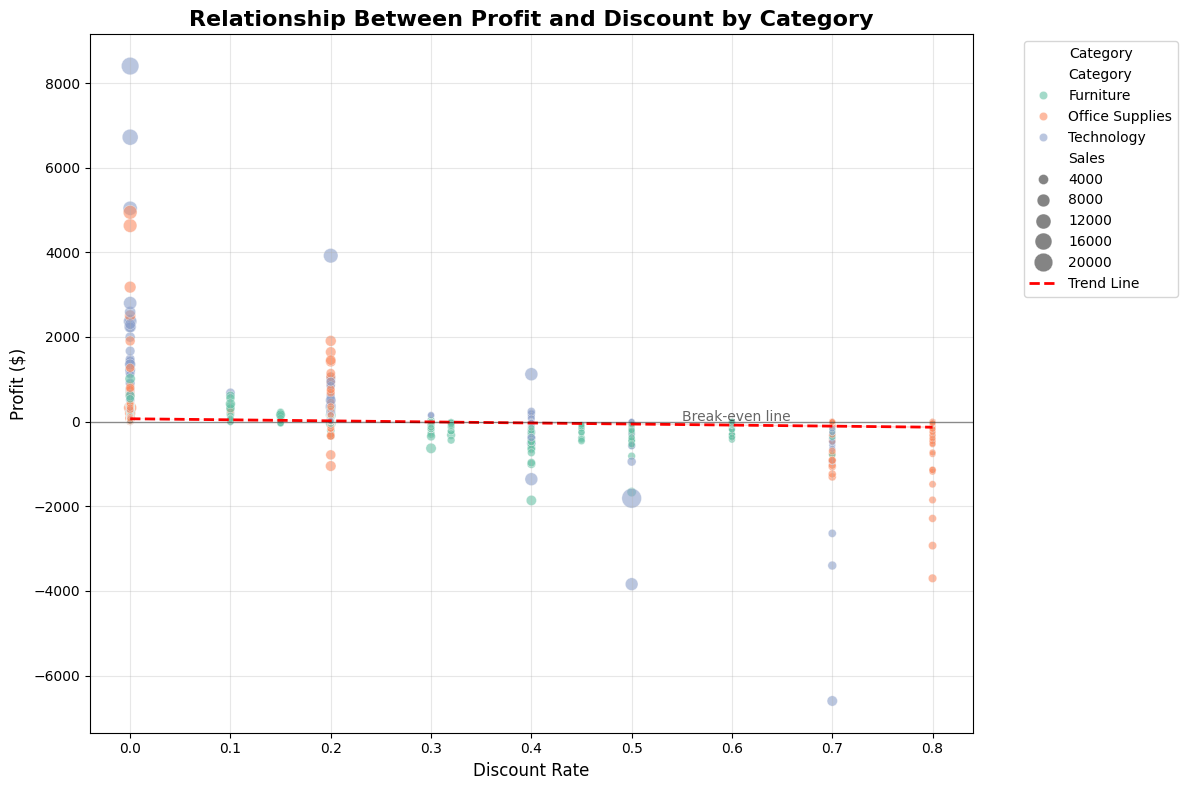


Discount Impact:
  Transactions with >20% discount    : 1,393
  Avg profit for high discounts      : $-97.18
  Loss rate at >20% discount         : 96.8%

      COMPARATIVE ANALYSIS : MATPLOTLIB VS SEABORN

MATPLOTLIB:
Strengths:
    Fine-grained control over every element
    Better for interactive and animated charts
    More flexible for custom layouts
    Easier integration with ipywidgets
Weaknesses:
    More verbose code for simple charts
    Default styling is less polished
    Statistical plots require more manual work

SEABORN:
Strengths:
    Publication-ready styling out of the box
    Built-in statistical visualizations (regplot, heatmap)
    Automatic color palettes and legends
    Less code for complex statistical charts
Weaknesses:
    Less control over fine details
    Slower for large datasets
    Limited interactivity

RECOMMENDATION:
Use Matplotlib for   : interactive dashboards, custom layouts
Use Seaborn for      : statistical analysis, executive reports


        

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PART 1 : DATA PREPARATION
# ============================================================

df = pd.read_excel(
    r"C:\Users\Utilisateur\OneDrive\Desktop\DI-Bootcamp-May\Week2\Day5\Exercice\US Superstore data.xls"
)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst rows:")
print(df.head())

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df['Order Year'] = df['Order Date'].dt.year
df['Order Month']= df['Order Date'].dt.month
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df = df.drop_duplicates()

print("\nData after preprocessing:")
print(df[['Order Date', 'Order Year', 'Sales', 'Profit', 'Profit Margin']].head())

# ============================================================
# PART 2 : DATA VISUALIZATION WITH MATPLOTLIB
# ============================================================

# --- Interactive Line Chart : Sales Trends Over Years ---

yearly_sales = df.groupby('Order Year')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(
    yearly_sales['Order Year'],
    yearly_sales['Sales'],
    marker='o',
    color='steelblue',
    linewidth=2.5,
    markersize=10,
    markerfacecolor='red',
    markeredgecolor='black'
)

for _, row in yearly_sales.iterrows():
    plt.annotate(
        f"${row['Sales']:,.0f}",
        xy=(row['Order Year'], row['Sales']),
        xytext=(0, 15),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='steelblue'
    )

plt.fill_between(
    yearly_sales['Order Year'],
    yearly_sales['Sales'],
    alpha=0.1,
    color='steelblue'
)

plt.title('Sales Trends Over the Years', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(yearly_sales['Order Year'], fontsize=11)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150)
plt.show()

print("\nYearly Sales Summary:")
print(yearly_sales)

# --- Sales Distribution by State (Map alternative with bar chart) ---

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(state_sales)))
bars = plt.barh(
    state_sales.index[::-1],
    state_sales.values[::-1],
    color=colors[::-1],
    edgecolor='black',
    alpha=0.9
)
for bar, value in zip(bars, state_sales.values[::-1]):
    plt.text(
        value + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${value:,.0f}',
        va='center',
        fontsize=9
    )
plt.title('Sales Distribution by State (Top 20)', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('state_sales.png', dpi=150)
plt.show()

# ============================================================
# PART 3 : DATA VISUALIZATION WITH SEABORN
# ============================================================

# --- Bar Chart : Top 10 Products by Sales ---

top10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=top10_products.values,
    y=top10_products.index,
    palette='viridis',
    orient='h'
)
for i, value in enumerate(top10_products.values):
    ax.text(
        value + 100,
        i,
        f'${value:,.0f}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )
plt.title('Top 10 Products by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top10_products.png', dpi=150)
plt.show()

print("\nTop 10 Products by Sales:")
print(top10_products)

# --- Scatter Plot : Profit vs Discount ---

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    size='Sales',
    sizes=(20, 200),
    alpha=0.6,
    palette='Set2'
)
sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    label='Trend Line'
)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)
plt.text(0.55, 20, 'Break-even line', fontsize=10, alpha=0.6)
plt.title('Relationship Between Profit and Discount by Category',
        fontsize=16, fontweight='bold')
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('profit_discount.png', dpi=150)
plt.show()

high_discount = df[df['Discount'] > 0.2]
print("\nDiscount Impact:")
print(f"  Transactions with >20% discount    : {len(high_discount):,}")
print(f"  Avg profit for high discounts      : ${high_discount['Profit'].mean():.2f}")
print(f"  Loss rate at >20% discount         : {(high_discount['Profit'] < 0).mean()*100:.1f}%")

# ============================================================
# PART 4 : COMPARATIVE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("      COMPARATIVE ANALYSIS : MATPLOTLIB VS SEABORN")
print("=" * 60)

print("""
MATPLOTLIB:
Strengths:
    Fine-grained control over every element
    Better for interactive and animated charts
    More flexible for custom layouts
    Easier integration with ipywidgets
Weaknesses:
    More verbose code for simple charts
    Default styling is less polished
    Statistical plots require more manual work

SEABORN:
Strengths:
    Publication-ready styling out of the box
    Built-in statistical visualizations (regplot, heatmap)
    Automatic color palettes and legends
    Less code for complex statistical charts
Weaknesses:
    Less control over fine details
    Slower for large datasets
    Limited interactivity

RECOMMENDATION:
Use Matplotlib for   : interactive dashboards, custom layouts
Use Seaborn for      : statistical analysis, executive reports
""")

# ============================================================
# PART 5 : KEY INSIGHTS
# ============================================================

total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
best_year     = yearly_sales.loc[yearly_sales['Sales'].idxmax(), 'Order Year']
best_state    = state_sales.index[0]
best_product  = top10_products.index[0]

print("\n" + "=" * 60)
print("              KEY INSIGHTS")
print("=" * 60)
print(f"\nSALES PERFORMANCE:")
print(f"  Total Revenue          : ${total_sales:,.0f}")
print(f"  Total Profit           : ${total_profit:,.0f}")
print(f"  Overall Profit Margin  : {profit_margin:.1f}%")
print(f"  Best Year              : {best_year}")
print(f"\nGEOGRAPHIC INSIGHTS:")
print(f"  Top State by Sales     : {best_state}")
print(f"  Top State Sales        : ${state_sales.iloc[0]:,.0f}")
print(f"\nPRODUCT INSIGHTS:")
print(f"  Top Product            : {best_product}")
print(f"  Top Product Sales      : ${top10_products.iloc[0]:,.0f}")
print(f"\nDISCOUNT INSIGHTS:")
print(f"  Loss rate >20% discount: {(high_discount['Profit'] < 0).mean()*100:.1f}%")
print(f"  Recommendation         : Cap discounts at 20%")
print("=" * 60)